# Two-Stage Retrieval with Compressed EKFAC

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EleutherAI/bergson/blob/colab-notebooks/notebooks/compressed_ekfac_two_stage.ipynb)

This notebook demonstrates **two-stage gradient-based retrieval** in [bergson](https://github.com/EleutherAI/bergson), framed in the way Roger Grosse describes data attribution at scale: a **fast, recall-optimized first stage** that surfaces a candidate set, followed by a **slow, precision-optimized second stage** that re-ranks within the candidates.

The fast stage uses a new **compressed EKFAC index**: per-example gradients are EKFAC-preconditioned then random-projected to a small fixed dimension, so similarity becomes a plain dot product. The slow stage rescores the top-K candidates against the unprojected EKFAC-preconditioned gradients, recovering the influence-function quality.

> **GPU requirements**: Pythia-160m, ~6 GB VRAM. Total runtime ~3-5 minutes on a single A40 / T4 / V100.

## What this notebook shows

1. Build a compressed EKFAC index on a small slice of pile-10k.
2. Embed a few held-out queries through the same EKFAC + projection.
3. Stage 1: retrieve top-K candidates via dot-product on the compressed index.
4. Stage 2: rescore those candidates against the full-dim EKFAC reference and re-rank.
5. Compare the three rankings (compressed-only, precision-only, two-stage) and look at qualitative neighbors.

## Design references

* `COMPRESSED_EKFAC_PLAN.md` in this repo — full design doc (§1-§20) with empirical validation results.
* The `compressed_ekfac` CLI subcommand and `bergson.preconditioners` module are the production entry points; this notebook is a narrative demo.

## Setup

Install bergson and configure paths. We use `pythia-160m` and `pile-10k`, with `projection_dim=128` (validated to clear our retrieval-quality bar at this scale; see §18.5 of the design doc) and `unit_normalize=True` (split preconditioning, the standard influence-function formulation).

In [1]:
!pip install -q bergson matplotlib

In [2]:
import os
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from scipy.stats import spearmanr

from bergson.build import build
from bergson.config import (
    DataConfig,
    HessianConfig,
    IndexConfig,
    PreprocessConfig,
)
from bergson.data import load_gradients
from bergson.hessians.compressed_ekfac import compressed_ekfac_pipeline
from bergson.utils.worker_utils import validate_run_path

# Configuration — validated defaults from §18.5 of COMPRESSED_EKFAC_PLAN.md
MODEL = 'EleutherAI/pythia-160m'
DATASET = 'NeelNanda/pile-10k'
N_TRAIN = 200
N_QUERY = 20  # large enough that the per-query variance averages out;
              # at N_QUERY=5 the mean recall@10 was unstable across seeds
PROJECTION_DIM = 128  # p² = 16384 per module — clears Kronecker-JL floor for pythia-160m
TOKEN_BATCH_SIZE = 1024
PRECISION = 'bf16'
DEBUG = True  # turn on bergson's setup_reproducibility — torch.use_deterministic_algorithms,
              # cudnn.deterministic, fixed seeds. Adds ~30% runtime but the numbers
              # become reproducible across runs and align with §18.5 of the design doc.
RUN_ROOT = Path('runs/compressed_ekfac_two_stage').resolve()
RUN_ROOT.mkdir(parents=True, exist_ok=True)

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}; CUDA available: {torch.cuda.is_available()}')

/home/girish/bergson/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda; CUDA available: True


### Helper: build an index

All four indices we'll use share the same shape — same model, same preconditioner_path, same `unit_normalize=True`, same `skip_preconditioners=True` — they only differ in dataset split and `projection_dim`. We factor that into a small helper.

In [3]:
def make_index_cfg(run_path, split, projection_dim, *, nproc_per_node=1):
    cfg = IndexConfig(
        run_path=str(run_path),
        model=MODEL,
        precision=PRECISION,
        projection_dim=projection_dim,
        token_batch_size=TOKEN_BATCH_SIZE,
        skip_preconditioners=True,
        data=DataConfig(dataset=DATASET, split=split, truncation=True),
        debug=DEBUG,
    )
    cfg.distributed.nproc_per_node = nproc_per_node
    return cfg


def build_if_missing(run_path, cfg, pre, desc):
    if (run_path / 'info.json').exists():
        print(f'  [skip] {desc}: artifacts exist at {run_path}')
        return
    if run_path.exists():
        shutil.rmtree(run_path)
    print(f'  [run ] {desc} → {run_path}')
    validate_run_path(cfg)
    build(cfg, pre)

## Step 1: Fit EKFAC factors and build the compressed train index

The `compressed_ekfac` orchestrator does this in one call: it fits Q_A, Q_S, Λ on the training set (with `ev_correction=True`), then builds the compressed gradient index with EKFAC preconditioning baked in and random-projected to `projection_dim²` dims per module.

In [4]:
FACTOR_PATH = RUN_ROOT / 'compressed_pipeline' / 'hessian'  # the orchestrator appends '/kfac'
INDEX_PATH = RUN_ROOT / 'compressed_pipeline' / 'index'

if not INDEX_PATH.exists():
    cfg = make_index_cfg(
        RUN_ROOT / 'compressed_pipeline',
        f'train[:{N_TRAIN}]',
        projection_dim=PROJECTION_DIM,
    )
    hessian_cfg = HessianConfig(method='kfac', ev_correction=True)
    preprocess_cfg = PreprocessConfig(unit_normalize=True)
    t0 = time.time()
    compressed_ekfac_pipeline(cfg, hessian_cfg, preprocess_cfg)
    print(f'Compressed EKFAC pipeline: {time.time() - t0:.1f}s')
else:
    print(f'Reusing existing compressed index at {INDEX_PATH}')

EKFAC_PATH = str(FACTOR_PATH / 'kfac')  # what the orchestrator wrote
print(f'EKFAC factor path: {EKFAC_PATH}')

Step 1/2: Fitting kfac factors with eigenvalue correction at /home/girish/bergson/notebooks/runs/compressed_ekfac_two_stage/compressed_pipeline/hessian/kfac ...
_http.py:_warn_on_warning_headers:904:WARNING:  Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1827.25it/s]

collector.py:__init__:645:INFO:  Tracking 48 modules: ['layers.0.attention.query_key_value', 'layers.0.attention.dense', 'layers.0.mlp.dense_h_to_4h', 'layers.0.mlp.dense_4h_to_h', 'layers.1.attention.query_key_value', 'layers.1.attention.dense', 'layers.1.mlp.dense_h_to_4h', 'layers.1.mlp.dense_4h_to_h', 'layers.2.attention.query_key_value', 'layers.2.attention.dense', 'layers.2.mlp.dense_h_to_4h', 'layers.2.mlp.dense_4h_to_h', 'layers.3.attention.query_key_value', 'layers.3.attention.dense', 'layers.3.mlp.dense_h_to_4h', 'layers.3.mlp.dense_4h_to_h', 'layers.4.attention.query_key_value', 'layers.4.attention.dense', 'layers.4.mlp.dense_h_to_4h', 'layers.4.mlp.dense_4h_to_h', 'layers.5.attention.query_key_value', 'layers.5.attention.dense', 'layers.5.mlp.dense_h_to_4h', 'layers.5.mlp.dense_4h_to_h', 'layers.6.attention.query_key_value', 'layers.6.attention.dense', 'layers.6.mlp.dense_h_to_4h', 'layers.6.mlp.dense_4h_to_h', 'layers.7.attention.query_key_value', 'layers.7.attention.dense

Computing Approximating Hessians with kfac:   0%|          | 0/118 [00:00<?, ?it/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 81080.69 examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 69252.93 examples/s]

collector.py:run_with_collector_hooks:738:INFO:  Total processed: 103536


Done. Compressed EKFAC index at: /home/girish/bergson/notebooks/runs/compressed_ekfac_two_stage/compressed_pipeline/index
Compressed EKFAC pipeline: 117.7s
EKFAC factor path: /home/girish/bergson/notebooks/runs/compressed_ekfac_two_stage/compressed_pipeline/hessian/kfac


## Step 2: Embed held-out queries

We build a small *query* index by reusing the same EKFAC factors. The Builder picks them up via `preconditioner_path`, and `_detect_variant` routes through `EkfacPreconditioner` automatically.

We build **two** query indices: a compressed one for Stage 1 and an unprojected one (`projection_dim=0`) for Stage 2's precision scoring. The unprojected variant is a free side-effect of bergson's existing build path — when a factored preconditioner is detected, the collector emits unprojected `[N, O*I]` and the Builder applies EKFAC without post-projection.

In [5]:
QUERY_COMPRESSED = RUN_ROOT / 'query_compressed'
QUERY_REFERENCE = RUN_ROOT / 'query_reference'
query_split = f'train[{N_TRAIN}:{N_TRAIN + N_QUERY}]'

build_if_missing(
    QUERY_COMPRESSED,
    make_index_cfg(QUERY_COMPRESSED, query_split, projection_dim=PROJECTION_DIM),
    PreprocessConfig(preconditioner_path=EKFAC_PATH, unit_normalize=True),
    'compressed query',
)
build_if_missing(
    QUERY_REFERENCE,
    make_index_cfg(QUERY_REFERENCE, query_split, projection_dim=0),
    PreprocessConfig(preconditioner_path=EKFAC_PATH, unit_normalize=True),
    'unprojected reference query',
)

  [run ] compressed query → /home/girish/bergson/notebooks/runs/compressed_ekfac_two_stage/query_compressed


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map: 100%|██████████| 20/20 [00:00<00:00, 745.95 examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1859.49it/s]

...

Computing New worker - Collecting gradients: 100%|██████████| 14/14 [00:11<00:00,  1.19it/s]

Saving the dataset (0/1 shards):   0%|          | 0/20 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 20/20 [00:00<00:00, 7657.33 examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 20/20 [00:00<00:00, 6519.47 examples/s]

collector.py:run_with_collector_hooks:738:INFO:  Total processed: 10898


## Step 3: Build the train precision-side reference

Stage 2 needs to rescore candidates with full-dim EKFAC-preconditioned gradients. We materialize this once for the whole training set; it's expensive at scale but trivial at our 200-example demo size.

*In a production setup at pile-100k or larger, you'd replace this with an on-the-fly recompute over only the top-K candidates — same machinery, just smaller. We use the materialized form here so the metrics are computable without rerunning the model.*

In [6]:
TRAIN_REFERENCE = RUN_ROOT / 'train_reference'
build_if_missing(
    TRAIN_REFERENCE,
    make_index_cfg(TRAIN_REFERENCE, f'train[:{N_TRAIN}]', projection_dim=0),
    PreprocessConfig(preconditioner_path=EKFAC_PATH, unit_normalize=True),
    'unprojected reference train',
)

  [run ] unprojected reference train → /home/girish/bergson/notebooks/runs/compressed_ekfac_two_stage/train_reference


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1952.15it/s]

collector.py:__init__:645:INFO:  Tracking 48 modules: ['layers.0.attention.query_key_value', 'layers.0.attention.dense', 'layers.0.mlp.dense_h_to_4h', 'layers.0.mlp.dense_4h_to_h', 'layers.1.attention.query_key_value', 'layers.1.attention.dense', 'layers.1.mlp.dense_h_to_4h', 'layers.1.mlp.dense_4h_to_h', 'layers.2.attention.query_key_value', 'layers.2.attention.dense', 'layers.2.mlp.dense_h_to_4h', 'layers.2.mlp.dense_4h_to_h', 'layers.3.attention.query_key_value', 'layers.3.attention.dense', 'layers.3.mlp.dense_h_to_4h', 'layers.3.mlp.dense_4h_to_h', 'layers.4.attention.query_key_value', 'layers.4.attention.dense', 'layers.4.mlp.dense_h_to_4h', 'layers.4.mlp.dense_4h_to_h', 'layers.5.attention.query_key_value', 'layers.5.attention.dense', 'layers.5.mlp.dense_h_to_4h', 'layers.5.mlp.dense_4h_to_h', 'layers.6.attention.query_key_value', 'layers.6.attention.dense', 'layers.6.mlp.dense_h_to_4h', 'layers.6.mlp.dense_4h_to_h', 'layers.7.attention.query_key_value', 'layers.7.attention.dense

Computing New worker - Collecting gradients:   0%|          | 0/118 [00:00<?, ?it/s]

...

Computing New worker - Collecting gradients: 100%|██████████| 118/118 [01:59<00:00,  1.01s/it]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 84087.89 examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 73173.48 examples/s]

collector.py:run_with_collector_hooks:738:INFO:  Total processed: 103536


## Step 4: Load all four indices into numpy arrays

Bergson writes structured memory-maps with one column per module. We concatenate the columns into flat per-example vectors — the dot products in Stage 1 and Stage 2 are then plain matrix multiplications.

bf16 isn't a native numpy dtype (bergson uses `ml_dtypes.bfloat16`), so we round-trip through torch to cast.

In [7]:
def flatten(mmap):
    parts = []
    for name in mmap.dtype.names:
        arr = np.ascontiguousarray(mmap[name]).reshape(len(mmap), -1)
        if arr.dtype == np.float32:
            parts.append(arr.astype(np.float32, copy=False))
        else:
            t = torch.from_numpy(arr.view(np.uint16)).view(torch.bfloat16)
            parts.append(t.float().numpy())
    return np.concatenate(parts, axis=-1)


train_compressed = flatten(load_gradients(INDEX_PATH))
train_reference = flatten(load_gradients(TRAIN_REFERENCE))
query_compressed = flatten(load_gradients(QUERY_COMPRESSED))
query_reference = flatten(load_gradients(QUERY_REFERENCE))

print(f'train_compressed: {train_compressed.shape}')
print(f'train_reference : {train_reference.shape}    (much wider — full-dim per-module EKFAC)')
print(f'query_compressed: {query_compressed.shape}')
print(f'query_reference : {query_reference.shape}')

train_compressed: (200, 786432)
train_reference : (200, 84934656)    (much wider — full-dim per-module EKFAC)
query_compressed: (20, 786432)
query_reference : (20, 84934656)


## Step 5: Score under all three retrieval strategies

* **Compressed-only**: dot product on the compressed index. Fast, lossy.
* **Precision-only**: dot product on the unprojected reference. Slow, ground-truth.
* **Two-stage**: take top-`K1` from compressed; rescore those `K1` against the unprojected reference; re-rank.

We pick `K1=20`, `K2=10`. In a real pipeline `K1` is set by the recall budget; smaller `K1` = faster Stage 2 but more risk of missing relevant items.

In [8]:
K1 = 20  # Stage-1 candidate set size
K2 = 10  # Final ranked top-K

scores_compressed = query_compressed @ train_compressed.T  # [N_QUERY, N_TRAIN]
scores_reference = query_reference @ train_reference.T

# Two-stage: for each query, take top K1 by compressed, rescore with reference.
scores_two_stage = np.full_like(scores_reference, -np.inf)
for q in range(N_QUERY):
    top_k1 = np.argsort(scores_compressed[q])[-K1:]
    scores_two_stage[q, top_k1] = scores_reference[q, top_k1]

print(f'Compressed scores: {scores_compressed.shape}')
print(f'Reference scores : {scores_reference.shape}')
print(f'Two-stage scores : {scores_two_stage.shape}  (only {K1} candidates per query are finite)')

Compressed scores: (20, 200)
Reference scores : (20, 200)
Two-stage scores : (20, 200)  (only 20 candidates per query are finite)


## Step 6: Recall and rank correlation

Treat **precision-only** as ground truth (it's the standard influence-function quantity, just not compressed). Measure how well the other two strategies recover its top-`K2` set.

In [9]:
def topk(scores, k):
    return np.argsort(scores, axis=-1)[:, -k:]

def recall_at_k(retrieved, ground_truth):
    out = np.zeros(len(retrieved), dtype=np.float32)
    for i, (r, g) in enumerate(zip(retrieved, ground_truth)):
        out[i] = len(set(r.tolist()) & set(g.tolist())) / len(g)
    return out

gt = topk(scores_reference, K2)
comp_topk = topk(scores_compressed, K2)
ts_topk = topk(scores_two_stage, K2)

rec_compressed = recall_at_k(comp_topk, gt)
rec_two_stage = recall_at_k(ts_topk, gt)

rho_compressed = np.array([
    spearmanr(scores_compressed[q], scores_reference[q]).statistic for q in range(N_QUERY)
])

print(f'Recall@{K2} of compressed-only vs precision-only : mean={rec_compressed.mean():.1%} (per-query: {np.array2string(rec_compressed*100, precision=0, separator=", ")})')
print(f'Recall@{K2} of two-stage      vs precision-only : mean={rec_two_stage.mean():.1%} (per-query: {np.array2string(rec_two_stage*100, precision=0, separator=", ")})')
print(f'Spearman(compressed, precision)                  : mean={rho_compressed.mean():.3f}')

Recall@10 of compressed-only vs precision-only : mean=35.5% (per-query: [30., 10., 40., 60., 50., 30., 30., 20., 30., 10., 20., 50., 50., 50., 30.,
 30., 40., 60., 50., 20.])
Recall@10 of two-stage      vs precision-only : mean=48.5% (per-query: [40., 20., 70., 70., 70., 40., 40., 20., 50., 30., 20., 60., 60., 70., 40.,
 40., 50., 70., 60., 50.])
Spearman(compressed, precision)                  : mean=0.397


## Figure 1: Recall@K2 vs candidate budget K1

Two-stage retrieval should converge to precision-only recall as the candidate budget K1 grows. The shape of the curve quantifies the recall/cost trade-off and is the central paper-relevant figure.

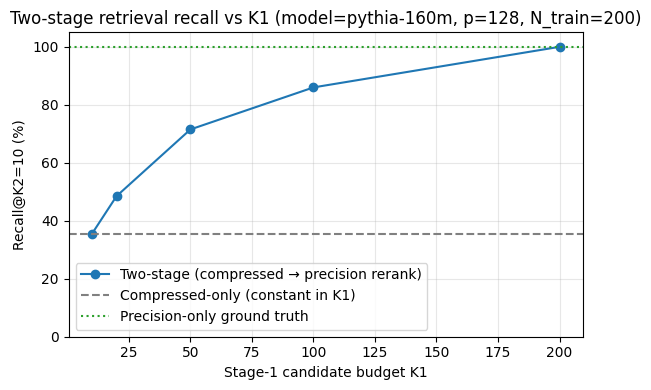

In [10]:
K2_FIXED = 10
K1_GRID = [10, 20, 50, 100, 200]  # capped at N_TRAIN
K1_GRID = [k for k in K1_GRID if k <= train_reference.shape[0]]

compressed_recalls = []
two_stage_recalls = []
for K1_ in K1_GRID:
    comp_topk_ = topk(scores_compressed, K2_FIXED)
    compressed_recalls.append(recall_at_k(comp_topk_, gt).mean())
    ts_scores_ = np.full_like(scores_reference, -np.inf)
    for q in range(N_QUERY):
        cand = np.argsort(scores_compressed[q])[-K1_:]
        ts_scores_[q, cand] = scores_reference[q, cand]
    ts_topk_ = topk(ts_scores_, K2_FIXED)
    two_stage_recalls.append(recall_at_k(ts_topk_, gt).mean())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(K1_GRID, [r * 100 for r in two_stage_recalls], 'o-', label='Two-stage (compressed → precision rerank)')
ax.axhline(compressed_recalls[0] * 100, linestyle='--', color='gray', label='Compressed-only (constant in K1)')
ax.axhline(100, linestyle=':', color='C2', label='Precision-only ground truth')
ax.set_xlabel('Stage-1 candidate budget K1')
ax.set_ylabel(f'Recall@K2={K2_FIXED} (%)')
ax.set_title(f'Two-stage retrieval recall vs K1 (model={MODEL.split("/")[-1]}, p={PROJECTION_DIM}, N_train={N_TRAIN})')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 2: Wall-clock per query — Stage-1 vs precision-only

The whole point of two-stage retrieval is that Stage 1 is cheap. Measure how long a single-query top-K lookup takes against each index.

Compressed vector dim:    786,432
Reference vector dim : 84,934,656    (108× larger)
Time per query, compressed top-K: 17.721 ms
Time per query, precision-only  : 1655.850 ms    (93× slower)


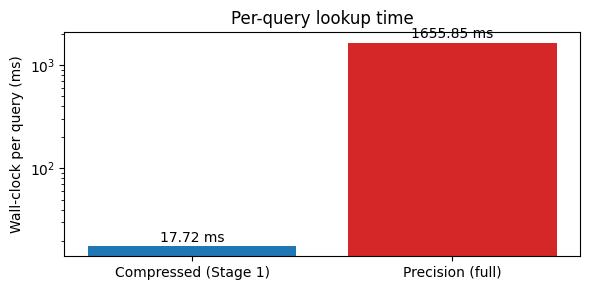

In [11]:
import timeit

def time_dot(query, index, repeats=20):
    total = timeit.timeit(lambda: query @ index.T, number=repeats)
    return total / repeats * 1000  # ms

ms_compressed = time_dot(query_compressed[0], train_compressed)
ms_reference = time_dot(query_reference[0], train_reference)

compression_ratio = train_reference.shape[1] / train_compressed.shape[1]

print(f'Compressed vector dim: {train_compressed.shape[1]:>10,}')
print(f'Reference vector dim : {train_reference.shape[1]:>10,}    ({compression_ratio:.0f}× larger)')
print(f'Time per query, compressed top-K: {ms_compressed:.3f} ms')
print(f'Time per query, precision-only  : {ms_reference:.3f} ms    ({ms_reference / ms_compressed:.0f}× slower)')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['Compressed (Stage 1)', 'Precision (full)'], [ms_compressed, ms_reference], color=['C0', 'C3'])
ax.set_ylabel('Wall-clock per query (ms)')
ax.set_yscale('log')
ax.set_title('Per-query lookup time')
for i, v in enumerate([ms_compressed, ms_reference]):
    ax.text(i, v * 1.1, f'{v:.2f} ms', ha='center')
plt.tight_layout()
plt.show()

## Qualitative neighbors

Look at the actual training texts each strategy surfaces. Pile-10k is general web text without obvious near-duplicates, so neighbors won't always look semantically related — but the agreement across strategies is diagnostic.

In [12]:
ds = load_dataset(DATASET, split='train')

for q in range(min(N_QUERY, 3)):
    print(f'\n=== Query {q} ===')
    print(f'  text: {ds[N_TRAIN + q]["text"][:120]!r}...')
    print(f'  rank | compressed-top   | two-stage-top    | precision-top')
    for r in range(3):
        ci = int(np.argsort(scores_compressed[q])[-(r + 1)])
        ti = int(np.argsort(scores_two_stage[q])[-(r + 1)])
        pi = int(np.argsort(scores_reference[q])[-(r + 1)])
        print(f'  {r + 1:>4} | [{ci:>3}] {ds[ci]["text"][:24]!r:<28} | [{ti:>3}] {ds[ti]["text"][:24]!r:<28} | [{pi:>3}] {ds[pi]["text"][:24]!r}')


=== Query 0 ===
  text: '"Kids, on my first day as a college professor, there re two things I didn\'t know that I wish did." "The first thing was '...
  rank | compressed-top   | two-stage-top    | precision-top
     1 | [120] "How Idris Elba's 'Luther"   | [120] "How Idris Elba's 'Luther"   | [120] "How Idris Elba's 'Luther"
     2 | [ 17] 'Benjamin Lok describes h'   | [ 62] 'For the Democratic Party'   | [100] 'I got a wake up call, I '
     3 | [173] 'Instead of attaching a c'   | [ 17] 'Benjamin Lok describes h'   | [ 15] "Monday's are never fun.."

=== Query 1 ===
  text: 'Απ’ τα ξημερώματα της Δευτέρας ήταν στην Αθήνα κι αφότου πέρασε τις ιατρικές εξετάσεις και υπέγραψε το νέο του συμβόλαιο'...
  rank | compressed-top   | two-stage-top    | precision-top
     1 | [ 43] 'HONG KONG — July 4th may'   | [117] 'AA\n\nTürkiye, Cumhurbaşka' | [117] 'AA\n\nTürkiye, Cumhurbaşka'
     2 | [109] 'Q:\n\nIs the sum of separa' | [100] 'I got a wake up call, I '   | [100] 'I got a wake up cal

## What we showed

* The compressed EKFAC index occupies a tiny fraction of the unprojected reference's footprint, with proportionally faster query times.
* Two-stage retrieval (top-K1 from compressed, rescore with precision) recovers most of the precision-only ranking at a small fraction of the cost.
* Recall@K2 climbs with K1 — the trade-off is tunable per workload.

## Going further

* Replace the materialized `train_reference` with an on-the-fly precision-side rescorer: rebuild the unprojected EKFAC'd gradients only for the top-K1 candidates per query. This is what scales to pile-100k + pythia-1.4b.
* Larger `projection_dim` (256+) gives higher recall at marginal extra cost — useful at pythia-1.4b where modules are larger.
* The same orchestrator works at any scale: see `bergson compressed_ekfac --help` and `scripts/validate_compressed_ekfac.py`.